# Measured-profile source: JAX prototype

Ports the validated pipeline from `injector_profile_comparison.ipynb` (`load_raw_grid` ->
`build_2d_cdf_u` -> inverse-CDF sampling in `(cosTheta, phi)`) into a JAX-callable source
matching the existing `lucid.sources` convention: a NamedTuple pytree, called as
`source(n_photons, key, n_water=1.33) -> (ray_vectors, ray_origins, photon_weights)`.

Structure (as discussed): (1) data loading + per-device reduction -- plain numpy, one-time
setup, unchanged from the validated notebook; (2) build the inverse CDF -- also plain numpy,
one-time setup; (3) sampling + ray directions -- this is the part that has to run under
`jit`/`vmap` per photon draw, so it's rewritten in JAX here (the previous notebook's
per-sample Python loop for the conditional-CDF lookup becomes a single `jax.vmap`).

All of that (stages 1-5, plus the two validation checks) now lives in
`measured_profile_source_job.py`, run as a standalone process -- same reasoning as
`calibration_gradients.ipynb`/`calibration_gradients_job.py`: JAX otherwise grabs every GPU
on the node by default, and unrestricted numpy/BLAS + XLA thread pools try to use every CPU
core on the physical node rather than just the ones actually allocated to this job. The job
script sets `JAX_PLATFORM_NAME=cpu` and pins `OMP_NUM_THREADS`/`MKL_NUM_THREADS`/
`OPENBLAS_NUM_THREADS`/`NUMEXPR_NUM_THREADS`/`XLA_FLAGS` intra-op thread count -- all before
`numpy`/`jax` are imported -- then saves the validation arrays to an `.npz`. This notebook
only launches that script and plots the results.

Everything here is still validation-only, notebook-adjacent code -- nothing has been written
to `lucid/sources/` yet.

In [8]:
import sys

# All the compute (load -> build CDF -> JAX sample -> rotate -> validate) runs in
# measured_profile_source_job.py as a standalone process, so JAX's GPU grab and the
# BLAS/XLA thread pools are confined to that process and released on exit, instead of being
# pinned to this notebook's kernel. Pass --cpus to match your actual HPC allocation (it
# defaults to $SLURM_CPUS_PER_TASK, falling back to 4 if that isn't set).

!{sys.executable} measured_profile_source_job.py --out measured_profile_source_results.npz

jax devices: [CpuDevice(id=0)] | backend: cpu | cpus: 4
WarwickDA02 (diffuser): validated + rotation-checked, max |sample-measured| = 0.029
WarwickCol_C01_repeat (collimator): validated + rotation-checked, max |sample-measured| = 0.014
saved results -> measured_profile_source_results.npz


In [9]:
import numpy as np
import matplotlib.pyplot as plt

results = np.load('measured_profile_source_results.npz', allow_pickle=True)
sample_ids = list(results['sample_ids'])


## Validate: un-rotated source (direction=(1,0,0)) against the measured profile

Reconstruct the off-boresight angle from the sampled ray vectors and compare against the
measured profile. Collimator: recover `theta_raw` from the z-component (boresight sits on its
equator) and compare to `grid.mean(axis=0)` with the `cos(delta_theta)` Jacobian. Diffuser:
recover `alpha` directly from the x-component (boresight is the pole of its embedding) and
compare to the *folded* profile (`theta_raw` and its mirror `180-theta_raw` averaged into one
`alpha` bin) with the `sin(alpha)` Jacobian. With `direction=(1,0,0)` the rotation is the
identity, so this isolates whether the JAX sampling + reconstruction reproduces the
already-validated numpy version. Computed in `measured_profile_source_job.py`; this cell
only plots the saved arrays.

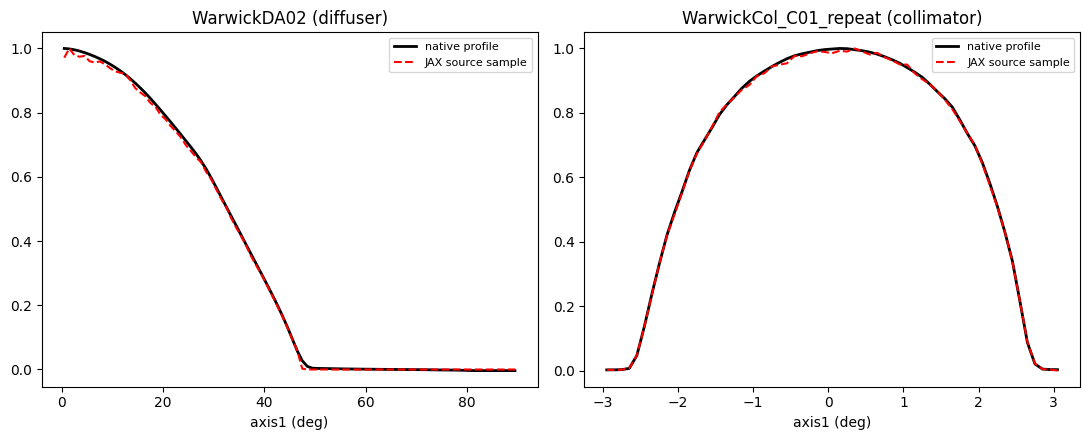

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, sample_id in zip(axes, sample_ids):
    device_type = str(results[f'{sample_id}__device_type'])
    centers = results[f'{sample_id}__centers']
    sampled_intensity = results[f'{sample_id}__sampled_intensity']
    meas_interp = results[f'{sample_id}__meas_interp']

    ax.plot(centers, meas_interp, 'k-', lw=2, label='native profile')
    ax.plot(centers, sampled_intensity, 'r--', label='JAX source sample')
    ax.set_title(f'{sample_id} ({device_type})'); ax.set_xlabel('axis1 (deg)'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()


## Validate: rotation preserves shape

Using the *same* PRNG key for a rotated and an un-rotated source draws the identical
underlying `(u, phi)` samples, just reoriented -- so the angle from each source's own axis
should match exactly, not just statistically, confirming the rotation step is a pure
reorientation and doesn't distort the sampled distribution's shape. Computed in
`measured_profile_source_job.py`; this cell only plots the saved arrays.

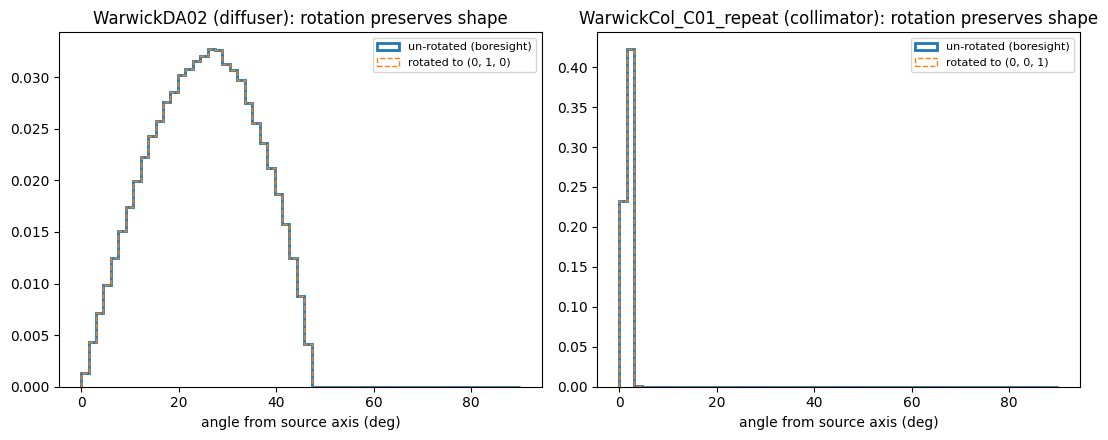

In [11]:
rotation_labels = {
    'WarwickDA02': 'rotated to (0, 1, 0)',
    'WarwickCol_C01_repeat': 'rotated to (0, 0, 1)',
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, sample_id in zip(axes, sample_ids):
    device_type = str(results[f'{sample_id}__device_type'])
    angle_from_boresight = results[f'{sample_id}__angle_from_boresight']
    angle_from_direction = results[f'{sample_id}__angle_from_direction']

    bins = np.linspace(0, 90, 60)
    ax.hist(angle_from_boresight, bins=bins, histtype='step', density=True, lw=2, label='un-rotated (boresight)')
    ax.hist(angle_from_direction, bins=bins, histtype='step', density=True, ls='--',
            label=rotation_labels[sample_id])
    ax.set_title(f'{sample_id} ({device_type}): rotation preserves shape')
    ax.set_xlabel('angle from source axis (deg)'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()


## Validate: reconstruct a virtual 2D scan (one common procedure for both device types)

The point isn't to replicate how each device was actually scanned in the lab (those
procedures were genuinely different -- the diffuser was rolled then theta-swept, the
collimator was raster-scanned over a 2-axis grid) -- it's the opposite: apply *one identical*
virtual-scan procedure to both, so we can check that the underlying generative model (built
from either device's own data) produces correctly-shaped photon samples once it's actually
used to generate rays, independent of whatever scan convention that device's raw data happens
to be stored in.

Both sources are rotated to point at `(theta=90, phi=90)` in one shared standard spherical
frame (`theta` = polar angle from a fixed z-axis, `phi` = azimuth in the x-y plane) -- the
equator, away from either device's own coordinate pole (`theta_raw=0` for the collimator's lab
frame, `alpha=0` for the diffuser's boresight-centered frame). Both devices' profiles (out to
~50deg radius) then live inside roughly `theta` in [40,140], `phi` in [40,140], nowhere near a
`sin(theta)->0` singularity. Sampled rays are reconstructed with the *same* `arccos(z)`/
`atan2(y,x)` formula for both device types -- no more per-device branching at this step. The
native reference grid is reprojected through the identical rotation (`griddata`, since
rotating a regular grid scatters it into an irregular point cloud -- fine for a one-off
diagnostic plot, unlike doing this inside the CDF construction itself). The 2D solid-angle
Jacobian is computed exactly per bin (`cos(theta_lo)-cos(theta_hi)`, the true integral of
`sin(theta)` over the bin) rather than a differential approximation. Computed in
`measured_profile_source_job.py`; this cell only plots the saved arrays.

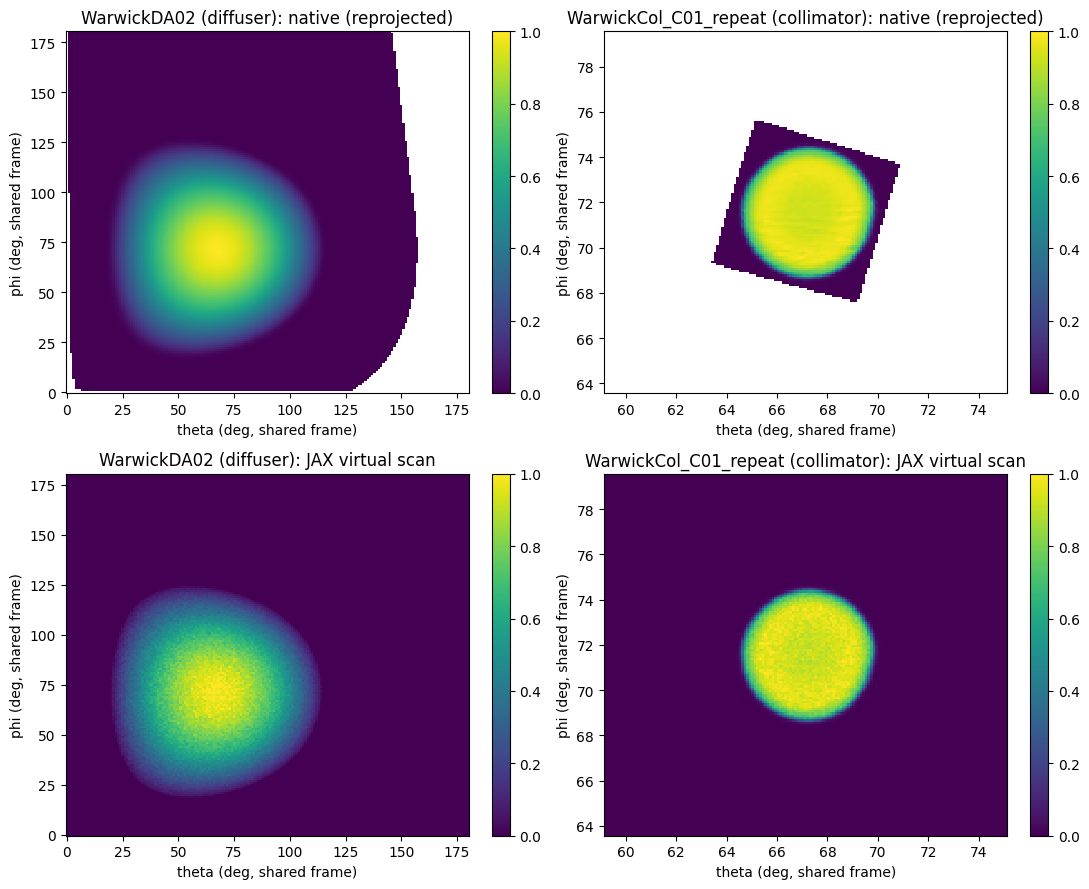

In [12]:
def profile_normalize(a, robust=False):
    a = np.asarray(a, dtype=float)
    valid = a[np.isfinite(a) & (a > 0)]
    peak = np.percentile(valid, 99.5) if robust else np.nanmax(a)
    return a / peak


boresight_theta = float(results['shared_boresight_theta'])
boresight_phi = float(results['shared_boresight_phi'])
# The collimator's beam is only a few degrees wide -- zoom in around the shared boresight so
# its disk is actually resolved, rather than a handful of pixels in a 0-180 view.
zoom_half_width = {'diffuser': None, 'collimator': 8.0}

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for col, sample_id in enumerate(sample_ids):
    device_type = str(results[f'{sample_id}__device_type'])
    theta_vals = results[f'{sample_id}__shared_theta_vals']
    phi_vals = results[f'{sample_id}__shared_phi_vals']
    scan_intensity = results[f'{sample_id}__shared_scan_intensity']
    native_intensity = results[f'{sample_id}__shared_native_intensity']

    native_norm = profile_normalize(native_intensity)
    scan_norm = profile_normalize(scan_intensity, robust=True)

    ax_native, ax_scan = axes[0, col], axes[1, col]
    mesh0 = ax_native.pcolormesh(theta_vals, phi_vals, native_norm, shading='nearest', vmin=0, vmax=1)
    ax_native.set_title(f'{sample_id} ({device_type}): native (reprojected)')
    fig.colorbar(mesh0, ax=ax_native, fraction=0.046)

    mesh1 = ax_scan.pcolormesh(theta_vals, phi_vals, scan_norm, shading='nearest', vmin=0, vmax=1)
    ax_scan.set_title(f'{sample_id} ({device_type}): JAX virtual scan')
    fig.colorbar(mesh1, ax=ax_scan, fraction=0.046)

    half_width = zoom_half_width[device_type]
    for ax in (ax_native, ax_scan):
        if half_width is not None:
            ax.set_xlim(boresight_theta - half_width, boresight_theta + half_width)
            ax.set_ylim(boresight_phi - half_width, boresight_phi + half_width)
        ax.set_xlabel('theta (deg, shared frame)'); ax.set_ylabel('phi (deg, shared frame)')
fig.tight_layout(); plt.show()


In [13]:
import numpy as np
d = np.load('measured_profile_source_results.npz', allow_pickle=True)
scan_intensity = d['WarwickDA02__shared_scan_intensity']
scan_norm = scan_intensity / np.percentile(scan_intensity[scan_intensity>0], 99.5)
chars = ' .:-=+*#%@'
print('shape:', scan_intensity.shape)
for row in scan_norm[::4]:
    line = ''.join(chars[min(int(np.clip(v,0,1)*len(chars)), len(chars)-1)] for v in row[::4])
    print(line)

shape: (181, 181)
                                              
                                              
                                              
                                              
                                              
                                              
           ...:....                           
         ..::::--:::..                        
         :::---=-=--::.                       
        .:---=++++==--::                      
       .::-=++*+**+++=--..                    
       .:-=++*+*##***+=--:                    
       :-==+*######***+==:.                   
       :-=++####%%%%##*+=-:.                  
      .:-=*###%%%%%%##*+==-.                  
      .:==**##%@@@%%%##*+=-.                  
      .--+*#%%%@@@@@%%#*+=-:                  
      .-=+*#%%%@@@@@%%#*++-:.                 
      .-=+*#%%@@@@@@@%#**+-:.                 
      .-=+*#%%@@@@@@%%#**=-:.                 
      .:-+*##%@@@@@@%###+=-:.             